In [180]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression

In [181]:
df = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Folder\daily-python-data-lab\04_machine_learning\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2026_1.csv", low_memory=False)

In [182]:
df.columns.to_list()

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'DOT_ID_Reporting_Airline',
 'IATA_CODE_Reporting_Airline',
 'Tail_Number',
 'Flight_Number_Reporting_Airline',
 'OriginAirportID',
 'OriginAirportSeqID',
 'OriginCityMarketID',
 'Origin',
 'OriginCityName',
 'OriginState',
 'OriginStateFips',
 'OriginStateName',
 'OriginWac',
 'DestAirportID',
 'DestAirportSeqID',
 'DestCityMarketID',
 'Dest',
 'DestCityName',
 'DestState',
 'DestStateFips',
 'DestStateName',
 'DestWac',
 'CRSDepTime',
 'DepTime',
 'DepDelay',
 'DepDelayMinutes',
 'DepDel15',
 'DepartureDelayGroups',
 'DepTimeBlk',
 'TaxiOut',
 'WheelsOff',
 'WheelsOn',
 'TaxiIn',
 'CRSArrTime',
 'ArrTime',
 'ArrDelay',
 'ArrDelayMinutes',
 'ArrDel15',
 'ArrivalDelayGroups',
 'ArrTimeBlk',
 'Cancelled',
 'CancellationCode',
 'Diverted',
 'CRSElapsedTime',
 'ActualElapsedTime',
 'AirTime',
 'Flights',
 'Distance',
 'DistanceGroup',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityD

In [183]:
df.isnull().sum()

Year                     0
Quarter                  0
Month                    0
DayofMonth               0
DayOfWeek                0
                     ...  
Div5TotalGTime      544003
Div5LongestGTime    544003
Div5WheelsOff       544003
Div5TailNum         544003
Unnamed: 109        544003
Length: 110, dtype: int64

In [184]:
null_percentage = df.isnull().mean() * 100

columns_to_drop = null_percentage[null_percentage > 50].index.tolist()

print("Columns to be dropped:", columns_to_drop)
print("Number of columns dropped:", len(columns_to_drop))

Columns to be dropped: ['CancellationCode', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'FirstDepTime', 'TotalAddGTime', 'LongestAddGTime', 'DivReachedDest', 'DivActualElapsedTime', 'DivArrDelay', 'DivDistance', 'Div1Airport', 'Div1AirportID', 'Div1AirportSeqID', 'Div1WheelsOn', 'Div1TotalGTime', 'Div1LongestGTime', 'Div1WheelsOff', 'Div1TailNum', 'Div2Airport', 'Div2AirportID', 'Div2AirportSeqID', 'Div2WheelsOn', 'Div2TotalGTime', 'Div2LongestGTime', 'Div2WheelsOff', 'Div2TailNum', 'Div3Airport', 'Div3AirportID', 'Div3AirportSeqID', 'Div3WheelsOn', 'Div3TotalGTime', 'Div3LongestGTime', 'Div3WheelsOff', 'Div3TailNum', 'Div4Airport', 'Div4AirportID', 'Div4AirportSeqID', 'Div4WheelsOn', 'Div4TotalGTime', 'Div4LongestGTime', 'Div4WheelsOff', 'Div4TailNum', 'Div5Airport', 'Div5AirportID', 'Div5AirportSeqID', 'Div5WheelsOn', 'Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff', 'Div5TailNum', 'Unnamed: 109']
Number of columns dropped: 54


In [185]:
df = df.drop(columns=columns_to_drop)
df.isnull().sum()

Year                                   0
Quarter                                0
Month                                  0
DayofMonth                             0
DayOfWeek                              0
FlightDate                             0
Reporting_Airline                      0
DOT_ID_Reporting_Airline               0
IATA_CODE_Reporting_Airline            0
Tail_Number                         4638
Flight_Number_Reporting_Airline        0
OriginAirportID                        0
OriginAirportSeqID                     0
OriginCityMarketID                     0
Origin                                 0
OriginCityName                         0
OriginState                            0
OriginStateFips                        0
OriginStateName                        0
OriginWac                              0
DestAirportID                          0
DestAirportSeqID                       0
DestCityMarketID                       0
Dest                                   0
DestCityName    

In [160]:
def fillnulls(dataframe):
    column=input("Enter Column Name:-")
    Q1= np.quantile(dataframe[column].dropna(),0.25)
    Q3= np.quantile(dataframe[column].dropna(),0.75)
    IQR=Q3-Q1
    lower_fence=Q1-(1.5*IQR)
    upper_fence=Q3+(1.5*IQR)

In [186]:
df.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'DOT_ID_Reporting_Airline',
       'IATA_CODE_Reporting_Airline', 'Tail_Number',
       'Flight_Number_Reporting_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest',
       'DestCityName', 'DestState', 'DestStateFips', 'DestStateName',
       'DestWac', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes',
       'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut',
       'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay',
       'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk',
       'Cancelled', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime',
       'AirTime', 'Flights', 'Distance', 'DistanceGroup',
       'DivAirportLandings'],
      

In [189]:
df.describe().columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'DOT_ID_Reporting_Airline', 'Flight_Number_Reporting_Airline',
       'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID',
       'OriginStateFips', 'OriginWac', 'DestAirportID', 'DestAirportSeqID',
       'DestCityMarketID', 'DestStateFips', 'DestWac', 'CRSDepTime', 'DepTime',
       'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups',
       'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime',
       'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups',
       'Cancelled', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime',
       'AirTime', 'Flights', 'Distance', 'DistanceGroup',
       'DivAirportLandings'],
      dtype='object')

In [196]:
id_columns = df.columns[df.columns.str.contains("ID", case=False, na=False)]

print("Columns to be removed:")
print(id_columns.tolist())
print(f"\nTotal columns: {len(id_columns)}")

Columns to be removed:
['DOT_ID_Reporting_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID']

Total columns: 7


In [197]:
df = df.loc[:, ~df.columns.str.contains("ID", case=False, na=False)]

In [194]:
list(set(df.columns)-set(df.describe().columns))

[]

In [192]:
df=df.drop(columns=X)

In [205]:
null_columns = df.columns[df.isnull().any()]

print(null_columns.tolist())

['DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ActualElapsedTime', 'AirTime']


In [206]:
numeric_cols = df.select_dtypes(include=['number']).columns

In [207]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    if outliers > 0:
        outlier_summary[col] = outliers

print(outlier_summary)

{'Flight_Number_Reporting_Airline': np.int64(296), 'DepDelay': np.int64(68235), 'DepDelayMinutes': np.int64(85027), 'DepDel15': np.int64(107297), 'DepartureDelayGroups': np.int64(71434), 'TaxiOut': np.int64(39198), 'TaxiIn': np.int64(41170), 'ArrDelay': np.int64(47114), 'ArrDelayMinutes': np.int64(84842), 'ArrDel15': np.int64(107475), 'ArrivalDelayGroups': np.int64(39181), 'Cancelled': np.int64(25635), 'Diverted': np.int64(1146), 'CRSElapsedTime': np.int64(26076), 'ActualElapsedTime': np.int64(23715), 'AirTime': np.int64(25372), 'Distance': np.int64(31612), 'DistanceGroup': np.int64(25272), 'DivAirportLandings': np.int64(1266)}


In [208]:
import pandas as pd

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Column", "Number of Outliers"]
)

outlier_df = outlier_df.sort_values(
    by="Number of Outliers",
    ascending=False
)

print(outlier_df)

                             Column  Number of Outliers
9                          ArrDel15              107475
3                          DepDel15              107297
2                   DepDelayMinutes               85027
8                   ArrDelayMinutes               84842
4              DepartureDelayGroups               71434
1                          DepDelay               68235
7                          ArrDelay               47114
6                            TaxiIn               41170
5                           TaxiOut               39198
10               ArrivalDelayGroups               39181
16                         Distance               31612
13                   CRSElapsedTime               26076
11                        Cancelled               25635
15                          AirTime               25372
17                    DistanceGroup               25272
14                ActualElapsedTime               23715
18               DivAirportLandings             

In [210]:
df.describe().columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'Flight_Number_Reporting_Airline', 'OriginStateFips', 'OriginWac',
       'DestStateFips', 'DestWac', 'CRSDepTime', 'DepTime', 'DepDelay',
       'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'TaxiOut',
       'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay',
       'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'Cancelled',
       'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Flights',
       'Distance', 'DistanceGroup', 'DivAirportLandings'],
      dtype='object')

# Flight Dataset Column Descriptions

## 1. Year
- **Meaning:** The calendar year in which the flight occurred.
- **Example:** 2026
- **Purpose:** Captures long-term operational trends and yearly changes.

---

## 2. Quarter
- **Meaning:** Quarter of the year.
- **Values:**
  - 1 = Jan–Mar
  - 2 = Apr–Jun
  - 3 = Jul–Sep
  - 4 = Oct–Dec
- **Purpose:** Helps identify seasonal travel patterns.

---

## 3. Month
- **Meaning:** Month number (1–12).
- **Purpose:** Captures seasonal effects such as holidays and weather.

---

## 4. DayofMonth
- **Meaning:** Day of the month (1–31).
- **Purpose:** Identifies daily travel demand patterns.

---

## 5. DayOfWeek
- **Meaning:** Day of the week.
- **Values:**
  - 1 = Monday
  - ...
  - 7 = Sunday
- **Purpose:** Weekend and weekday flights often have different delay patterns.

---

## 6. Flight_Number_Reporting_Airline
- **Meaning:** Flight number assigned by the airline.
- **Purpose:** Uniquely identifies scheduled flights.
- **Note:** Usually acts as an identifier rather than a predictive feature.

---

## 7. OriginStateFips
- **Meaning:** FIPS (Federal Information Processing Standard) code of the origin state.
- **Purpose:** Represents the departure state's geographical identifier.

---

## 8. OriginWac
- **Meaning:** World Area Code (WAC) of the origin airport.
- **Purpose:** Represents the geographical region of the departure airport.

---

## 9. DestStateFips
- **Meaning:** FIPS code of the destination state.
- **Purpose:** Identifies the geographical location of the destination airport.

---

## 10. DestWac
- **Meaning:** World Area Code (WAC) of the destination airport.
- **Purpose:** Represents the geographical region of the destination airport.

---

## 11. CRSDepTime
- **Meaning:** Scheduled departure time (Computer Reservation System).
- **Example:** 0830 = 8:30 AM
- **Purpose:** Planned departure time before the flight.

---

## 12. DepTime
- **Meaning:** Actual departure time.
- **Purpose:** Records when the aircraft actually departed.

---

## 13. DepDelay
- **Meaning:** Departure delay in minutes.
- **Values:**
  - Positive = Late departure
  - Negative = Early departure
  - Zero = On time
- **Purpose:** Strong predictor of arrival delay.

---

## 14. DepDelayMinutes
- **Meaning:** Positive departure delay only.
- **Example:**
  - DepDelay = -5
  - DepDelayMinutes = 0
- **Purpose:** Used for reporting total delay minutes.

---

## 15. DepDel15
- **Meaning:** Indicates whether the departure delay was 15 minutes or more.
- **Values:**
  - 1 = Yes
  - 0 = No
- **Purpose:** FAA on-time performance metric.

---

## 16. DepartureDelayGroups
- **Meaning:** Categorized departure delay group.
- **Purpose:** Groups delays into ranges for analysis.

---

## 17. TaxiOut
- **Meaning:** Time from leaving the gate until takeoff.
- **Unit:** Minutes
- **Purpose:** Measures airport ground congestion before takeoff.

---

## 18. WheelsOff
- **Meaning:** Actual takeoff time.
- **Purpose:** Records when the aircraft left the runway.

---

## 19. WheelsOn
- **Meaning:** Landing time.
- **Purpose:** Records when the aircraft touched down.

---

## 20. TaxiIn
- **Meaning:** Time from landing until reaching the gate.
- **Unit:** Minutes
- **Purpose:** Measures airport congestion after landing.

---

## 21. CRSArrTime
- **Meaning:** Scheduled arrival time.
- **Purpose:** Planned arrival time according to the flight schedule.

---

## 22. ArrTime
- **Meaning:** Actual arrival time.
- **Purpose:** Records when the aircraft actually arrived.

---

## 23. ArrDelay (Target Variable)
- **Meaning:** Arrival delay in minutes.
- **Values:**
  - Positive = Late arrival
  - Negative = Early arrival
  - Zero = On time
- **Purpose:** Target variable used for prediction.

---

## 24. ArrDelayMinutes
- **Meaning:** Positive arrival delay only.
- **Purpose:** Negative delays are converted to zero for reporting.

---

## 25. ArrDel15
- **Meaning:** Indicates whether arrival delay was at least 15 minutes.
- **Values:**
  - 1 = Yes
  - 0 = No
- **Purpose:** Standard airline performance metric.

---

## 26. ArrivalDelayGroups
- **Meaning:** Categorized arrival delay.
- **Purpose:** Groups delays into predefined intervals.

---

## 27. Cancelled
- **Meaning:** Indicates whether the flight was cancelled.
- **Values:**
  - 1 = Cancelled
  - 0 = Operated normally
- **Purpose:** Flight status indicator.

---

## 28. Diverted
- **Meaning:** Indicates whether the flight was diverted.
- **Values:**
  - 1 = Diverted
  - 0 = Not diverted
- **Purpose:** Shows whether the aircraft landed at an alternate airport.

---

## 29. CRSElapsedTime
- **Meaning:** Scheduled flight duration.
- **Unit:** Minutes
- **Purpose:** Planned travel time.

---

## 30. ActualElapsedTime
- **Meaning:** Actual total travel time.
- **Unit:** Minutes
- **Purpose:** Total journey duration from departure gate to arrival gate.

---

## 31. AirTime
- **Meaning:** Time spent in the air.
- **Unit:** Minutes
- **Formula:**
  ActualElapsedTime - TaxiOut - TaxiIn
- **Purpose:** Measures actual flying time.

---

## 32. Flights
- **Meaning:** Number of flights represented by the record.
- **Typical Value:** 1
- **Purpose:** Usually acts as a count variable and often has little predictive value.

---

## 33. Distance
- **Meaning:** Distance between origin and destination airports.
- **Unit:** Miles
- **Purpose:** Longer routes may exhibit different delay characteristics.

---

## 34. DistanceGroup
- **Meaning:** Categorized flight distance.
- **Purpose:** Groups flights into distance ranges for analysis.

---

## 35. DivAirportLandings
- **Meaning:** Number of diversion airport landings.
- **Typical Values:**
  - 0 = No diversion
  - 1 or more = One or more diversion landings
- **Purpose:** Indicates diversion events during the flight.

---

# Machine Learning Information

## Target Variable (Y)

```python
y = df["ArrDelay"]
```

The model predicts the **arrival delay (ArrDelay)** in minutes.

---

## Feature Variables (X)

```python
X = df.drop("ArrDelay", axis=1)
```

All remaining columns are used as input features to predict the arrival delay.

---

# Note on Data Leakage

Some columns such as:
- ArrTime
- ArrDelayMinutes
- ArrDel15
- ArrivalDelayGroups
- WheelsOn
- TaxiIn
- ActualElapsedTime
- AirTime

are only known after or during the flight. Using these variables to predict `ArrDelay` before departure would introduce **data leakage**, making the model unrealistically accurate. In a real-world deployment, only information available before departure should be used.

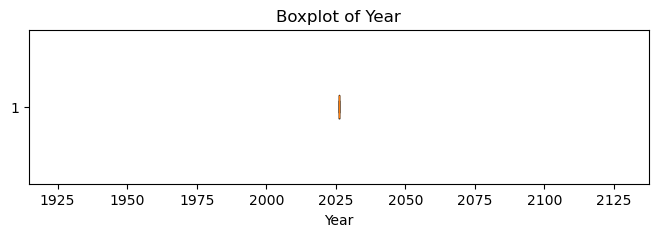

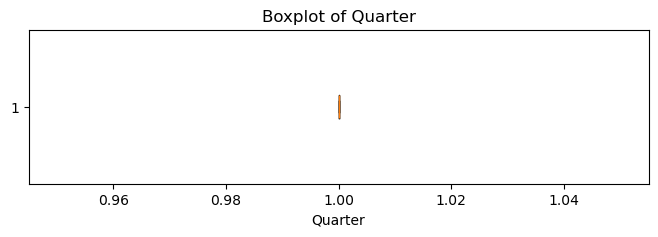

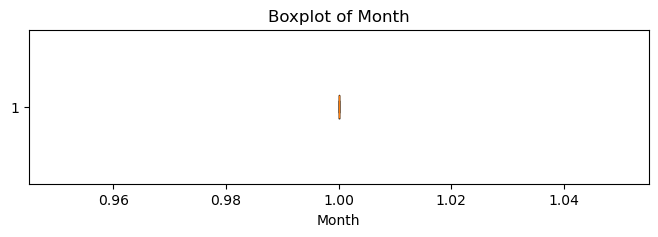

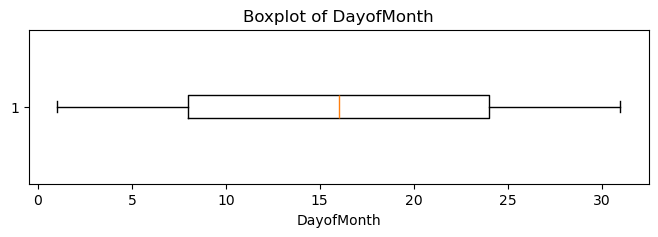

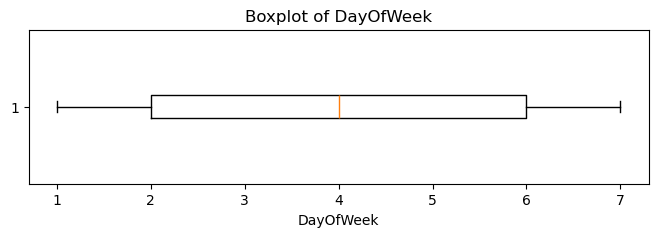

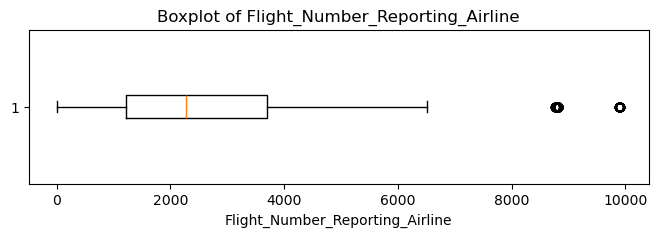

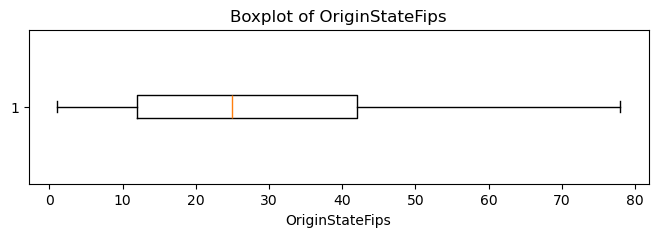

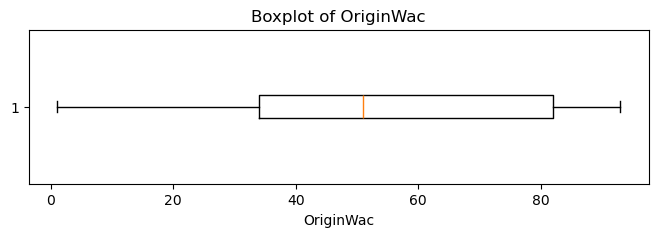

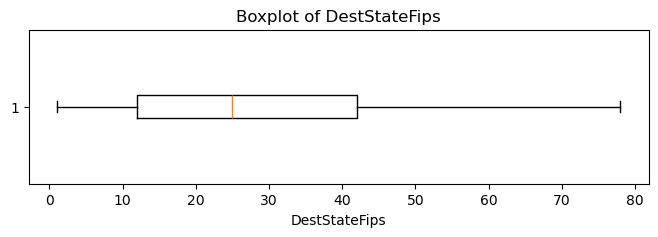

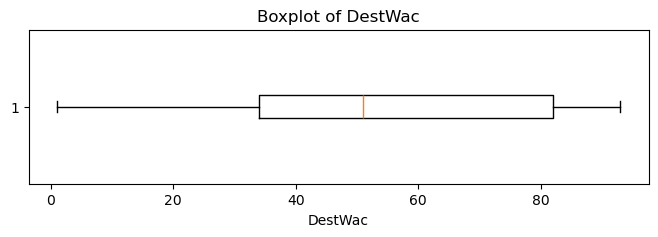

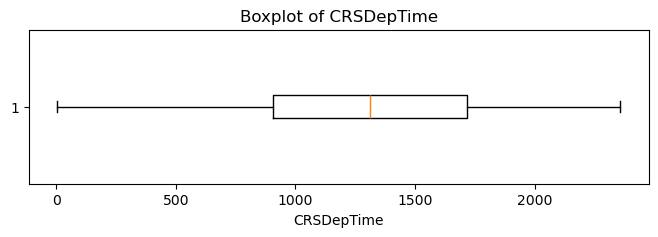

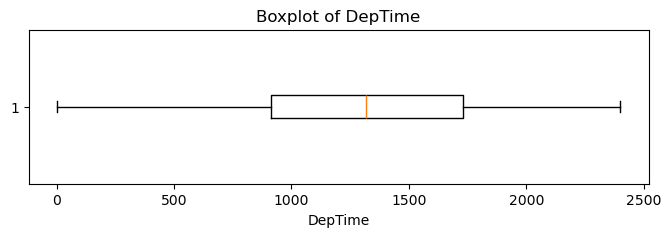

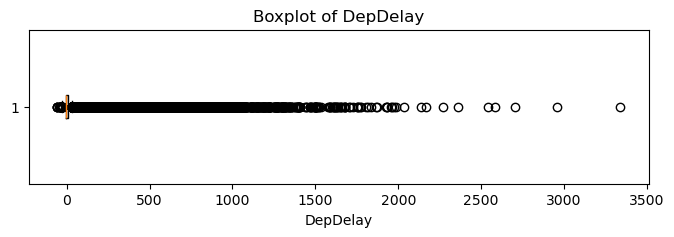

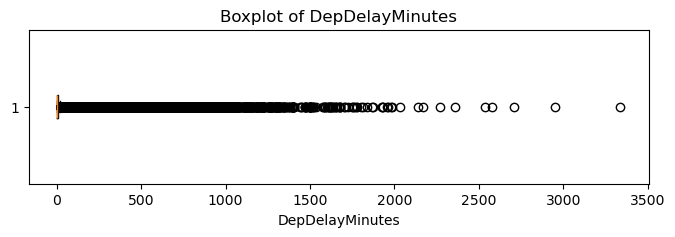

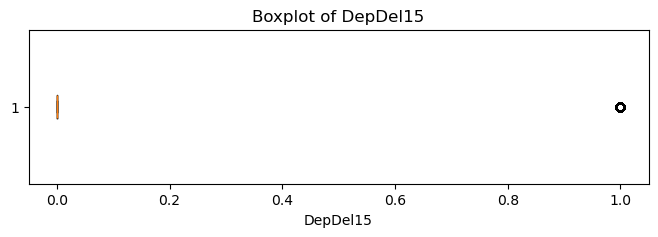

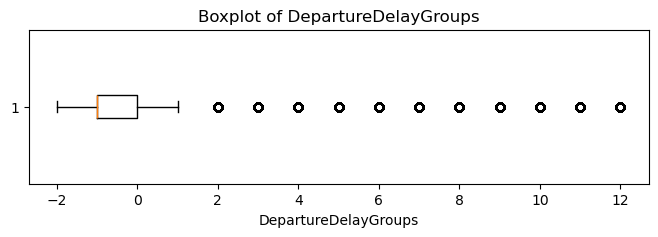

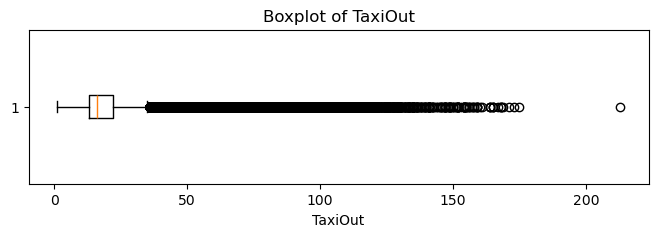

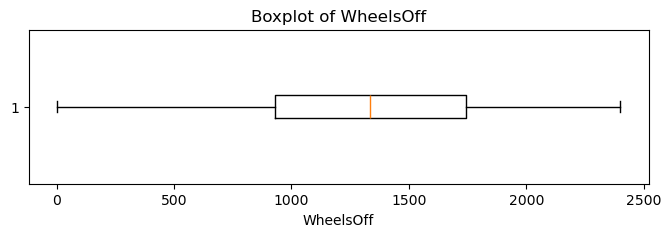

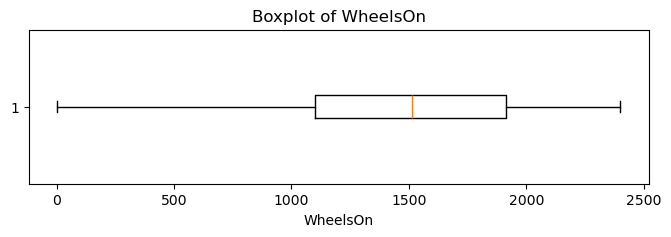

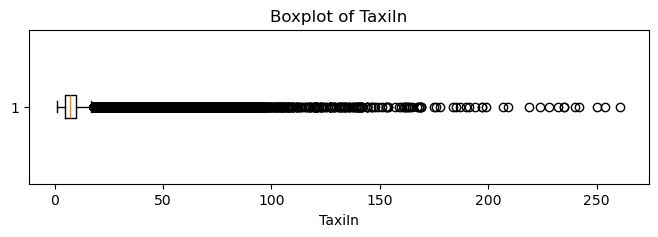

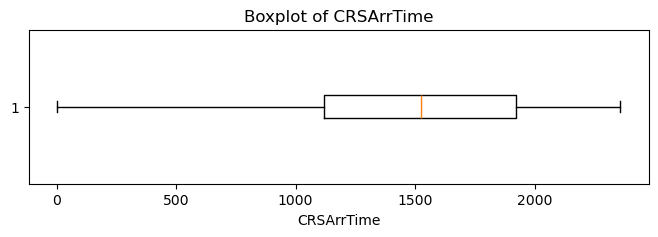

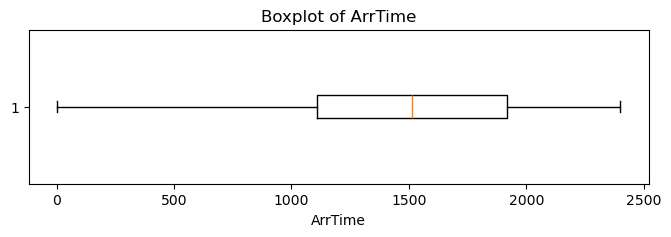

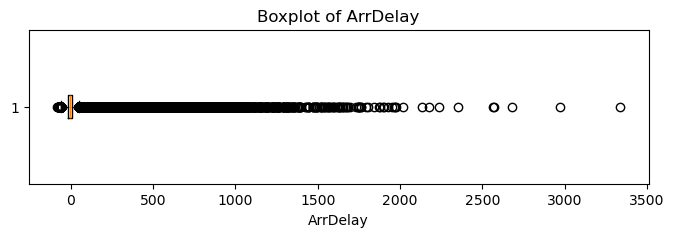

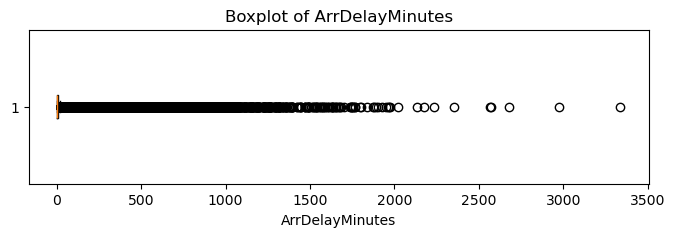

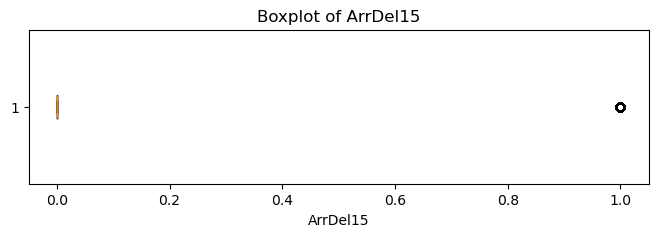

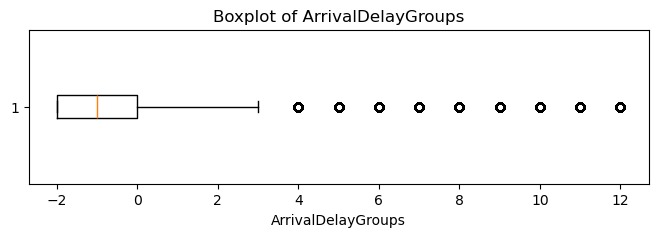

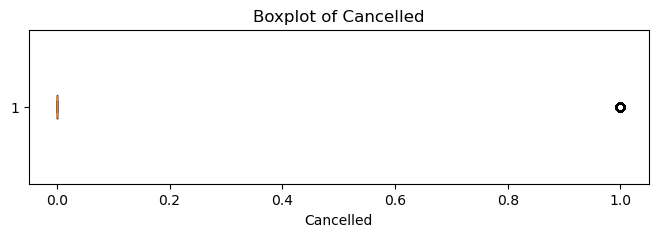

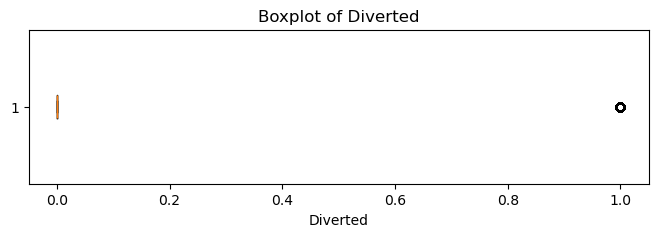

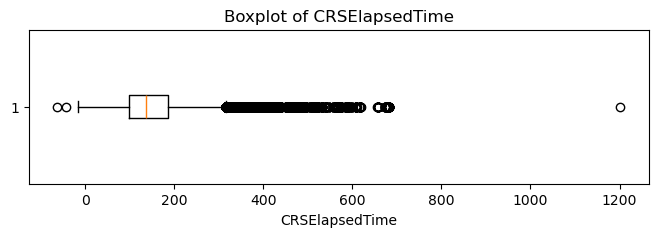

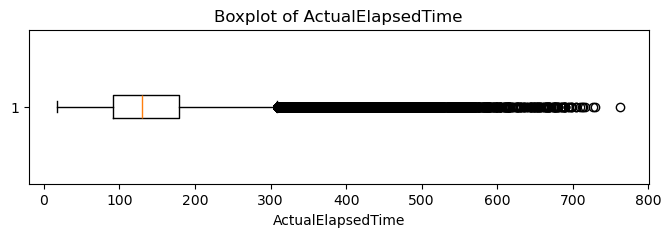

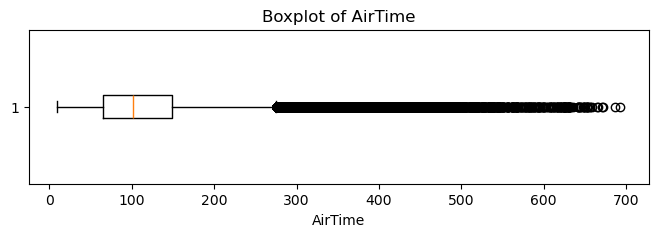

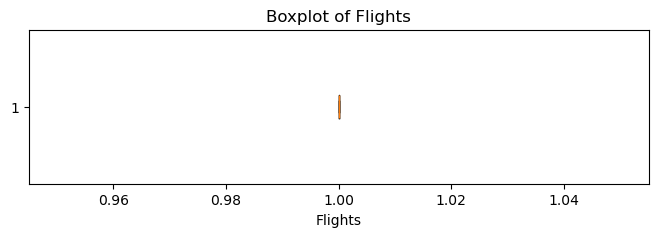

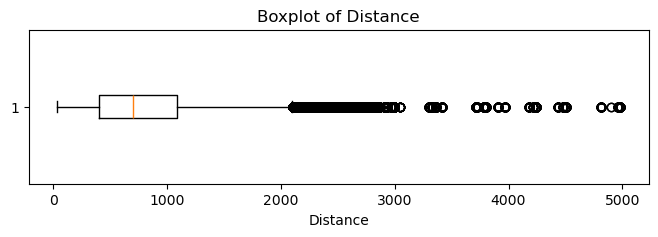

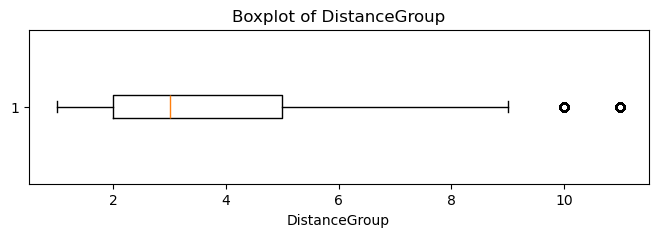

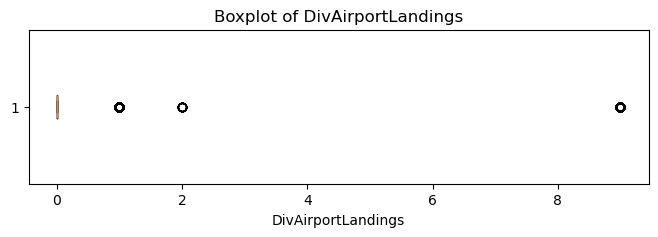

In [209]:
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

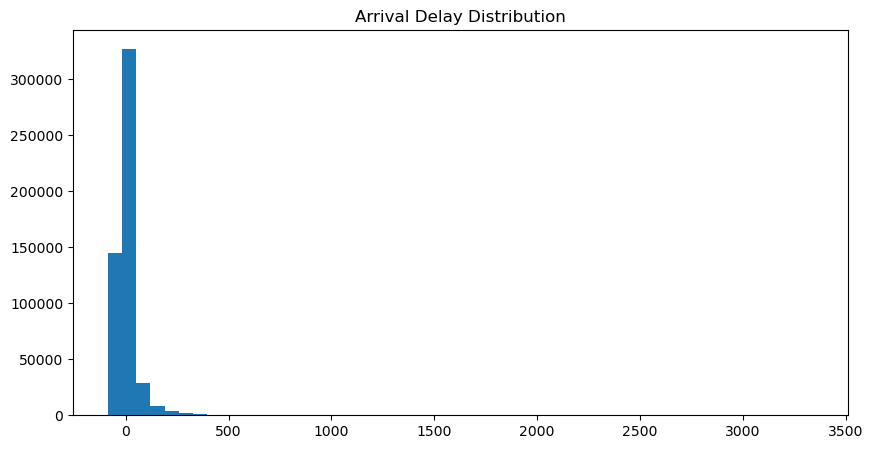

In [215]:
plt.figure(figsize=(10,5))
plt.hist(df["ArrDelay"], bins=50)
plt.title("Arrival Delay Distribution")
plt.show()

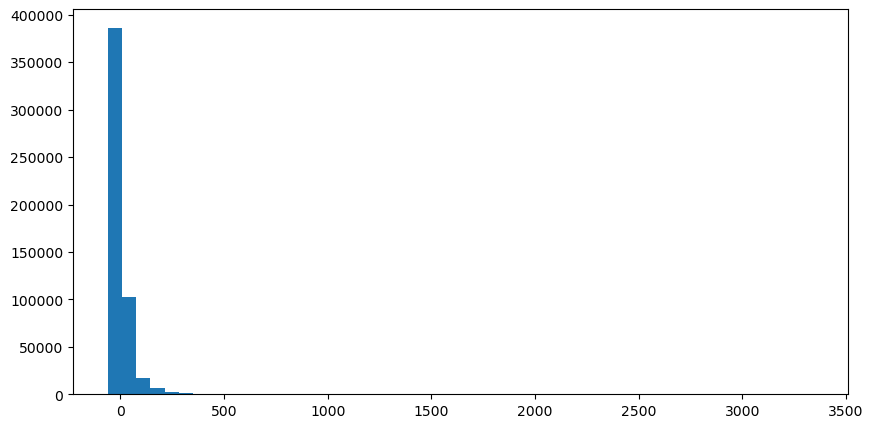

In [216]:
plt.figure(figsize=(10,5))
plt.hist(df["DepDelay"], bins=50)
plt.show()

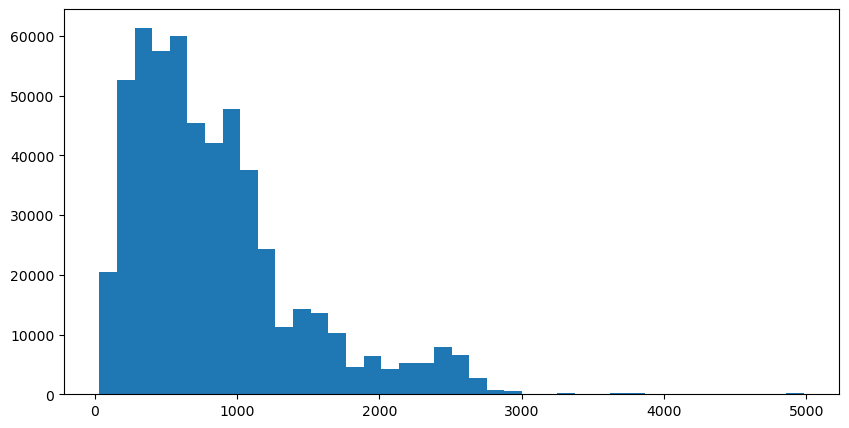

In [217]:
plt.figure(figsize=(10,5))
plt.hist(df["Distance"], bins=40)
plt.show()

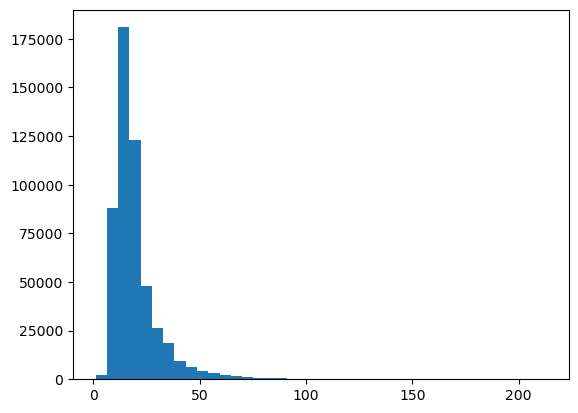

In [218]:
plt.hist(df["TaxiOut"], bins=40)
plt.show()

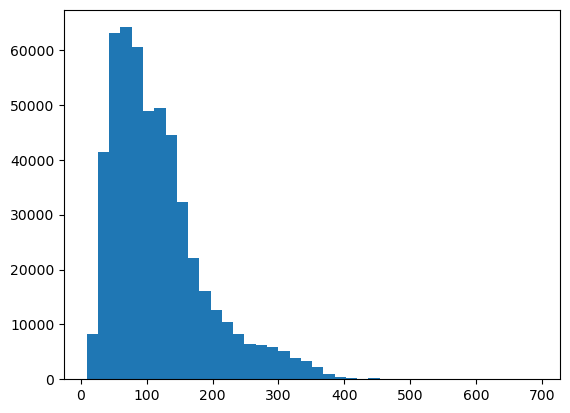

In [219]:
plt.hist(df["AirTime"], bins=40)
plt.show()

<Axes: >

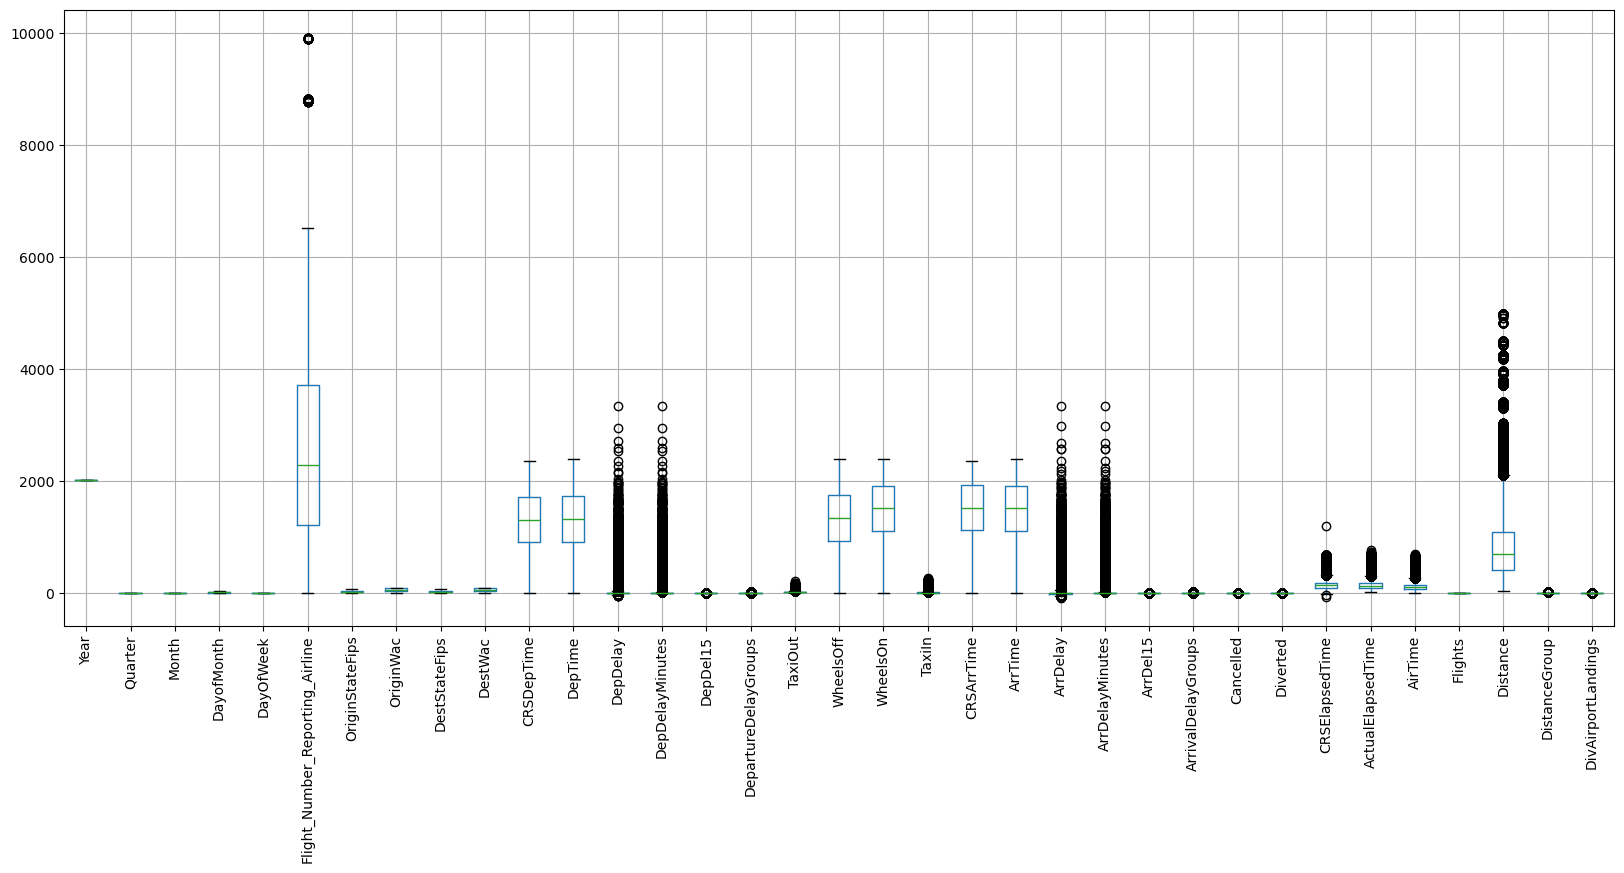

In [220]:
numeric=df.select_dtypes(include="number")

numeric.boxplot(figsize=(20,8),rot=90)

In [221]:
df["Cancelled"].value_counts()

Cancelled
0.0    518368
1.0     25635
Name: count, dtype: int64

<Axes: xlabel='Cancelled'>

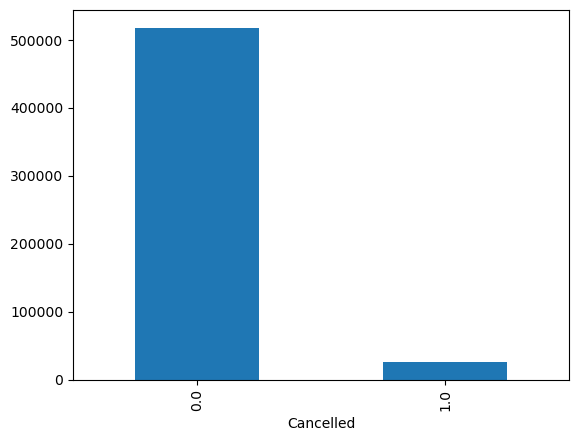

In [222]:
df["Cancelled"].value_counts().plot(kind="bar")

<Axes: xlabel='Diverted'>

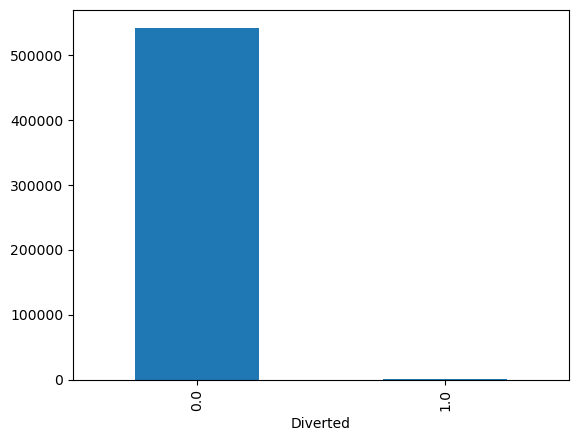

In [223]:
df["Diverted"].value_counts().plot(kind="bar")

<Axes: xlabel='Month'>

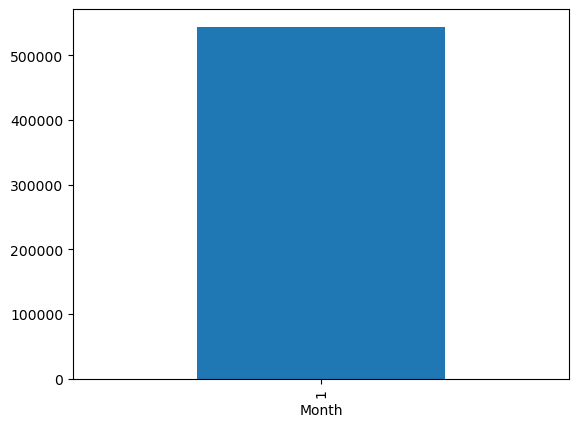

In [224]:
df["Month"].value_counts().sort_index().plot(kind="bar")

<Axes: xlabel='DayOfWeek'>

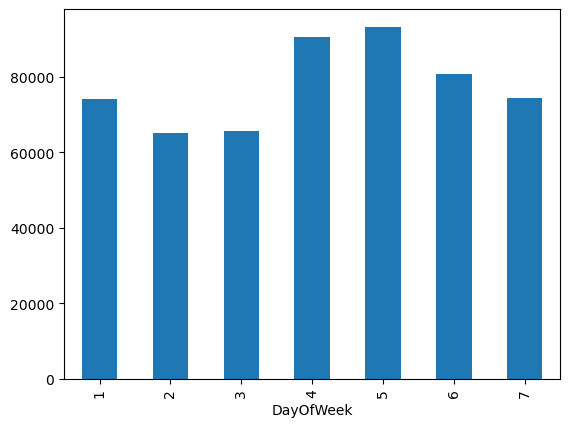

In [225]:
df["DayOfWeek"].value_counts().sort_index().plot(kind="bar")

<Axes: xlabel='Quarter'>

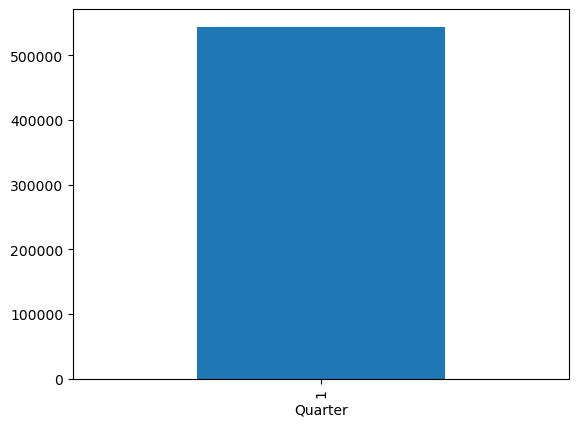

In [226]:
df["Quarter"].value_counts().plot(kind="bar")

<Axes: xlabel='DistanceGroup'>

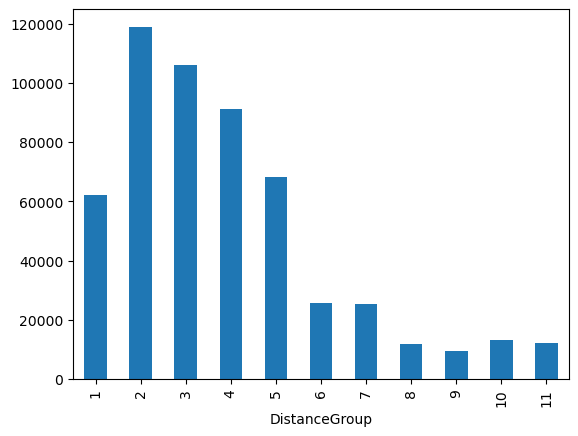

In [227]:
df["DistanceGroup"].value_counts().sort_index().plot(kind="bar")

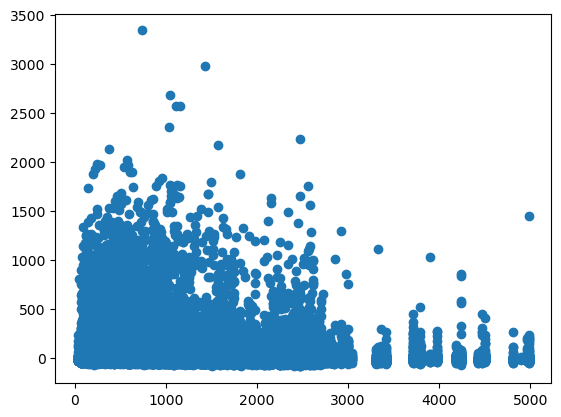

In [228]:
plt.scatter(df["Distance"],df["ArrDelay"])

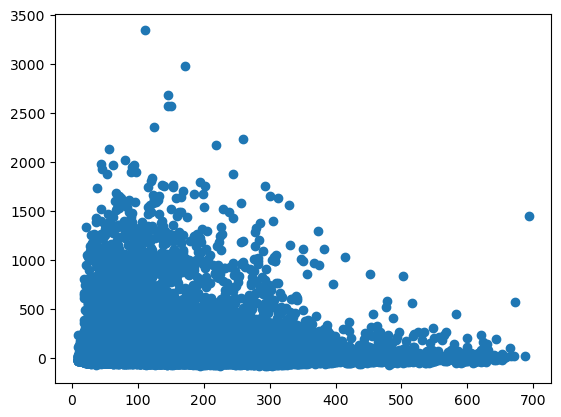

In [229]:
plt.scatter(df["AirTime"],df["ArrDelay"])

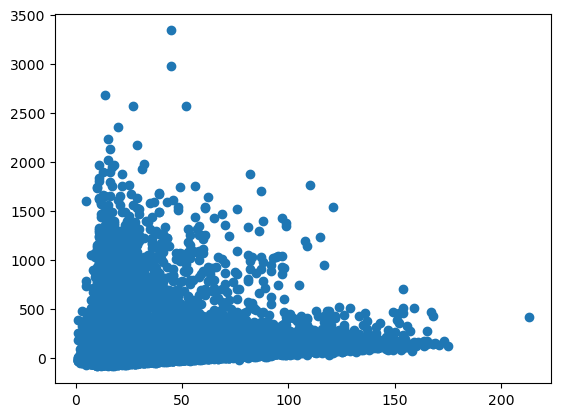

In [230]:
plt.scatter(df["TaxiOut"],df["ArrDelay"])

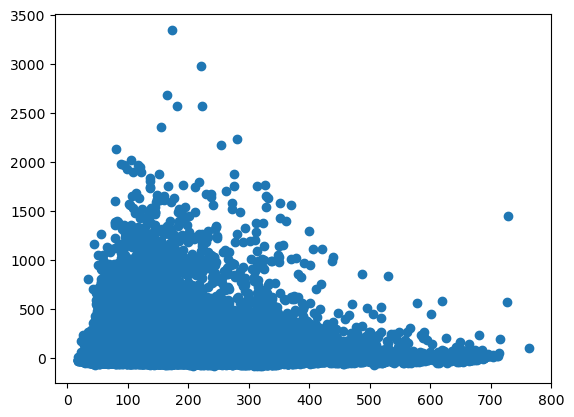

In [231]:
plt.scatter(df["ActualElapsedTime"],df["ArrDelay"])

In [233]:
corr=df.corr(numeric_only=True)

<Axes: >

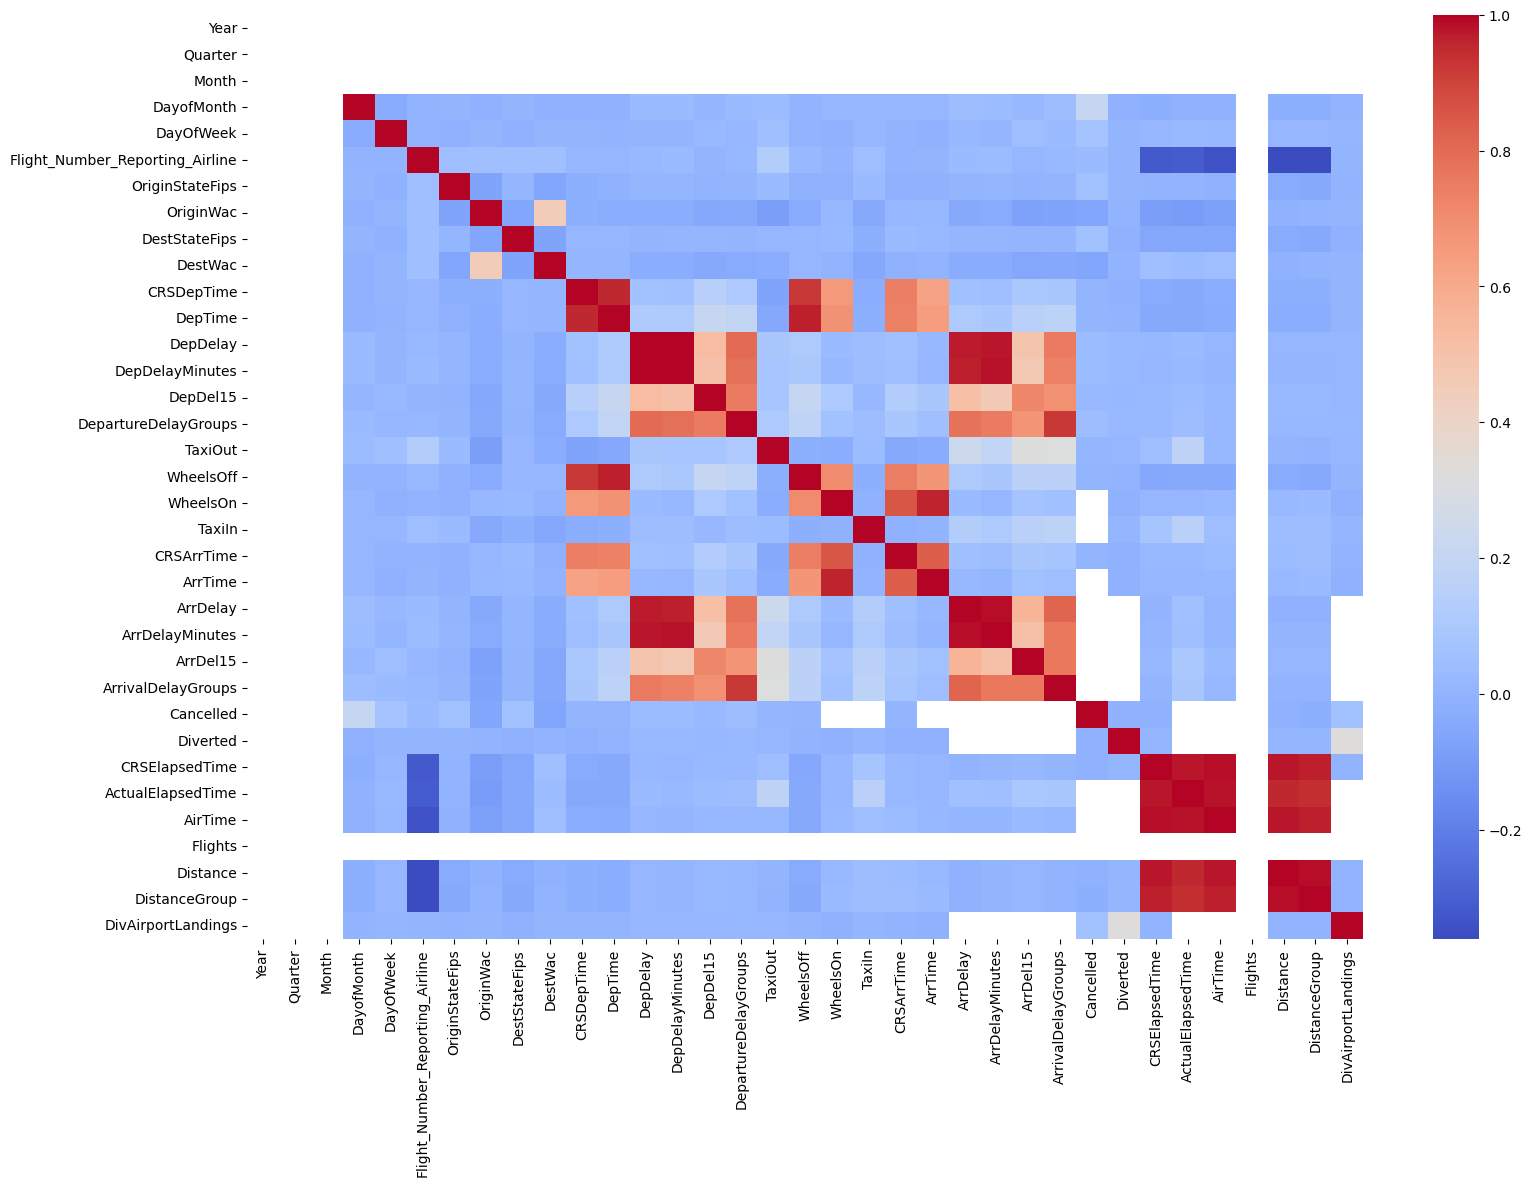

In [234]:
plt.figure(figsize=(18,12))
sns.heatmap(corr,cmap="coolwarm")

In [237]:
corr["ArrDelay"].sort_values(ascending=False)

ArrDelay                           1.000000
ArrDelayMinutes                    0.985761
DepDelay                           0.969261
DepDelayMinutes                    0.966866
ArrivalDelayGroups                 0.816376
DepartureDelayGroups               0.780454
ArrDel15                           0.559124
DepDel15                           0.516072
TaxiOut                            0.237003
TaxiIn                             0.130916
DepTime                            0.110440
WheelsOff                          0.108551
ActualElapsedTime                  0.058483
CRSDepTime                         0.057898
CRSArrTime                         0.052722
DayofMonth                         0.038542
WheelsOn                           0.029505
Flight_Number_Reporting_Airline    0.028035
ArrTime                            0.020157
DayOfWeek                          0.018555
AirTime                            0.008017
DestStateFips                      0.007911
OriginStateFips                 

<Axes: xlabel='Month', ylabel='ArrDelay'>

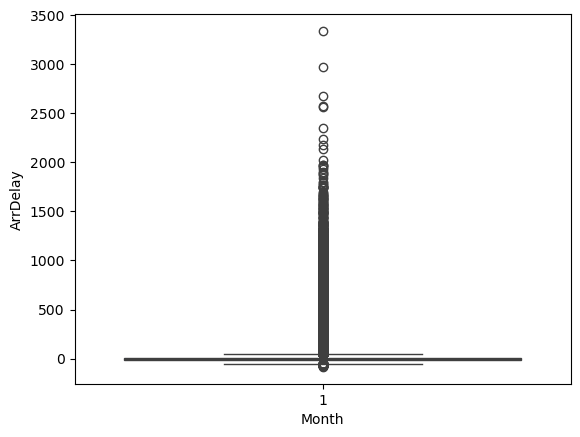

In [238]:
sns.boxplot(x="Month",y="ArrDelay",data=df)

<Axes: xlabel='Quarter', ylabel='ArrDelay'>

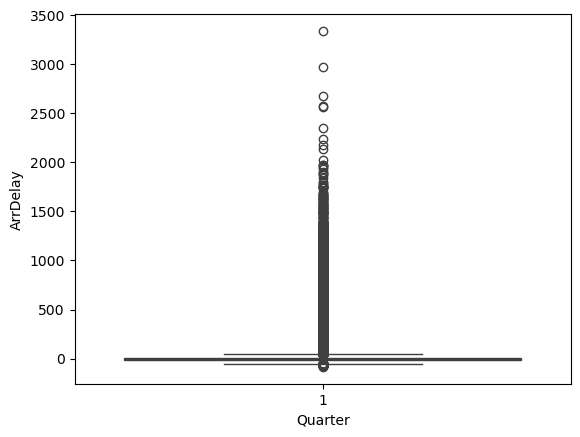

In [239]:
sns.boxplot(x="Quarter",y="ArrDelay",data=df)

<Axes: xlabel='DayOfWeek', ylabel='ArrDelay'>

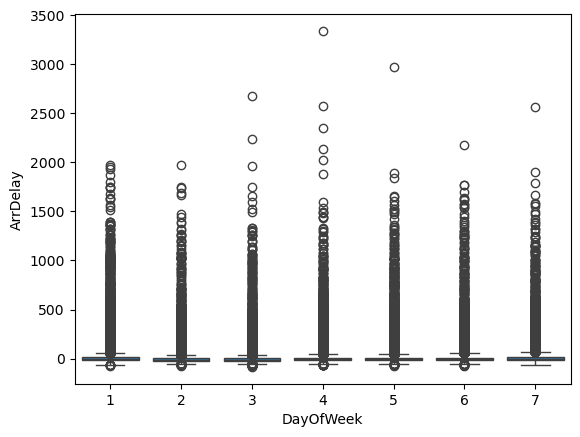

In [240]:
sns.boxplot(x="DayOfWeek",y="ArrDelay",data=df)

<Axes: xlabel='Cancelled', ylabel='ArrDelay'>

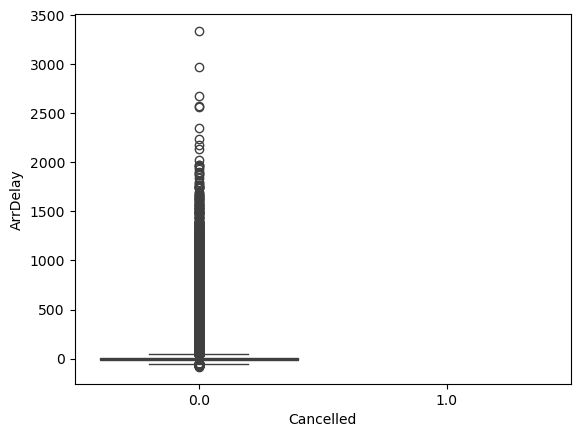

In [241]:
sns.boxplot(x="Cancelled",y="ArrDelay",data=df)

<Axes: xlabel='DistanceGroup', ylabel='ArrDelay'>

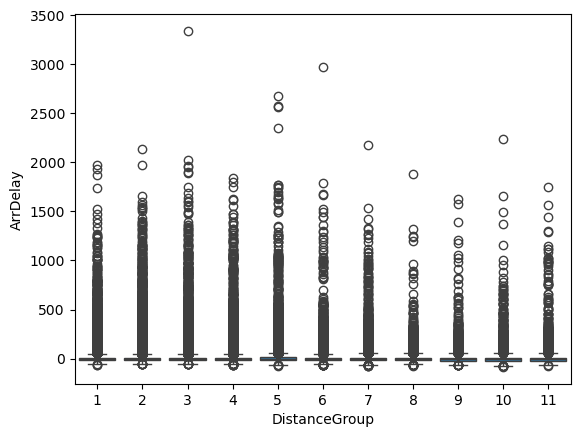

In [242]:
sns.boxplot(x="DistanceGroup",y="ArrDelay",data=df)

In [243]:
corr["ArrDelay"].sort_values()

OriginWac                         -0.042020
DestWac                           -0.035717
DistanceGroup                     -0.006555
Distance                          -0.005608
CRSElapsedTime                    -0.003635
OriginStateFips                    0.003446
DestStateFips                      0.007911
AirTime                            0.008017
DayOfWeek                          0.018555
ArrTime                            0.020157
Flight_Number_Reporting_Airline    0.028035
WheelsOn                           0.029505
DayofMonth                         0.038542
CRSArrTime                         0.052722
CRSDepTime                         0.057898
ActualElapsedTime                  0.058483
WheelsOff                          0.108551
DepTime                            0.110440
TaxiIn                             0.130916
TaxiOut                            0.237003
DepDel15                           0.516072
ArrDel15                           0.559124
DepartureDelayGroups            

In [244]:
df.isnull().sum().sort_values(ascending=False)

ArrivalDelayGroups                 26781
ArrDelayMinutes                    26781
AirTime                            26781
ActualElapsedTime                  26781
ArrDel15                           26781
ArrDelay                           26781
ArrTime                            25838
TaxiIn                             25838
WheelsOn                           25838
TaxiOut                            25515
WheelsOff                          25515
DepDelay                           25229
DepDelayMinutes                    25229
DepDel15                           25229
DepartureDelayGroups               25229
DepTime                            25164
Cancelled                              0
Diverted                               0
CRSElapsedTime                         0
Flights                                0
Distance                               0
DistanceGroup                          0
Year                                   0
CRSArrTime                             0
Quarter         

In [245]:
print(df.shape)

(544003, 35)


In [247]:
print(df["Cancelled"].value_counts())

print(df["Diverted"].value_counts())

Cancelled
0.0    518368
1.0     25635
Name: count, dtype: int64
Diverted
0.0    542857
1.0      1146
Name: count, dtype: int64


In [248]:
df.select_dtypes(include=["object"]).columns

Index([], dtype='object')

In [250]:
columns_to_drop = [
    "ArrTime",
    "ArrDelayMinutes",
    "ArrDel15",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime"
]

df.drop(columns=columns_to_drop, inplace=True)

In [253]:
departure_columns = [
    "DepTime",
    "DepDelay",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "TaxiOut",
    "WheelsOff"
]

df.drop(columns=departure_columns, inplace=True)

In [255]:
constant_cols = [
    col
    for col in df.columns
    if df[col].nunique() == 1
]

print(constant_cols)

['Year', 'Quarter', 'Month', 'Flights']


In [257]:
df.drop(columns=constant_cols, inplace=True)

In [258]:
df.columns

Index(['DayofMonth', 'DayOfWeek', 'Flight_Number_Reporting_Airline',
       'OriginStateFips', 'OriginWac', 'DestStateFips', 'DestWac',
       'CRSDepTime', 'CRSArrTime', 'ArrDelay', 'Cancelled', 'Diverted',
       'CRSElapsedTime', 'Distance', 'DistanceGroup', 'DivAirportLandings'],
      dtype='object')

In [259]:
corr = df.corr(numeric_only=True).abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print(high_corr)

['Distance', 'DistanceGroup']


In [260]:
X = df.drop("ArrDelay", axis=1)

y = df["ArrDelay"]

In [266]:
y.isnull().sum()

np.int64(0)

In [265]:
y = y.fillna(0)

In [267]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [268]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [270]:
y_pred = model.predict(X_test)

In [271]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 27.49048864749067
MSE : 3487.3604199439874
RMSE: 59.05387726427442
R²  : 0.008571762212849388


In [124]:
target_cols = ["ArrDelay","ArrDelayMinutes","ArrDel15","ArrivalDelayGroups"]

In [125]:
leakage_cols = ["DepTime","DepDelay","DepDelayMinutes","DepDel15","DepartureDelayGroups",
                "TaxiOut","WheelsOff","WheelsOn","TaxiIn","ArrTime","ActualElapsedTime","AirTime",
                "CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay"]

In [137]:
diversion_cols = [
    "FirstDepTime",
    "TotalAddGTime",
    "LongestAddGTime",
    "DivAirportLandings",
    "DivReachedDest",
    "DivActualElapsedTime",
    "DivArrDelay",
    "DivDistance",
    "Div1Airport","Div1AirportID","Div1AirportSeqID","Div1WheelsOn",
    "Div1TotalGTime","Div1LongestGTime","Div1WheelsOff","Div1TailNum",
    "Div2Airport","Div2AirportID","Div2AirportSeqID","Div2WheelsOn",
    "Div2TotalGTime","Div2LongestGTime","Div2WheelsOff","Div2TailNum",
    "Div3Airport","Div3AirportID","Div3AirportSeqID","Div3WheelsOn",
    "Div3TotalGTime","Div3LongestGTime","Div3WheelsOff","Div3TailNum",
    "Div4Airport","Div4AirportID","Div4AirportSeqID","Div4WheelsOn",
    "Div4TotalGTime","Div4LongestGTime","Div4WheelsOff","Div4TailNum",
    "Div5Airport","Div5AirportID","Div5AirportSeqID","Div5WheelsOn",
    "Div5TotalGTime","Div5LongestGTime","Div5WheelsOff","Div5TailNum"
]

In [138]:
id_cols = [
    "FlightDate",
    "Tail_Number",
    "Flight_Number_Reporting_Airline",
    "DOT_ID_Reporting_Airline",
    "OriginAirportSeqID",
    "DestAirportSeqID",
    "OriginAirportID",
    "DestAirportID",
    "OriginCityMarketID",
    "DestCityMarketID",
    "Unnamed: 109"
]

In [139]:
drop_cols = target_cols + leakage_cols + diversion_cols + id_cols

X = df.drop(columns=drop_cols, errors="ignore")

In [140]:
y = df['ArrDelay']

In [141]:
# df = df.dropna(subset=["ArrDelay"])

# X = df.drop(columns=drop_cols)

# y = df["ArrDelay"]

In [142]:
model = LinearRegression()

In [143]:
y = y.fillna(y.mean())
y.isna().sum()

np.int64(0)

In [144]:
y = y.fillna(y.median())

In [145]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [146]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
y_train_pred = model.predict(X_train)

In [148]:
y_test_pred = model.predict(X_test)

In [149]:
mean_absolute_error(y_train, y_train_pred)

27.844760956923263

In [150]:
mean_squared_error(y_train, y_train_pred)

3868.654193861926

In [151]:
np.sqrt(mean_squared_error(y_train, y_train_pred))

np.float64(62.19850636359306)

In [152]:
r2_score(y_train, y_train_pred)

0.007420772020047206

In [153]:
mean_absolute_error(y_test, y_test_pred)

27.481484446153562

In [154]:
mean_squared_error(y_test, y_test_pred)

3489.707370828741

In [155]:
np.sqrt(mean_squared_error(y_test, y_test_pred))

np.float64(59.073745190471385)

In [156]:
r2_score(y_test, y_test_pred)

0.00739250067182029

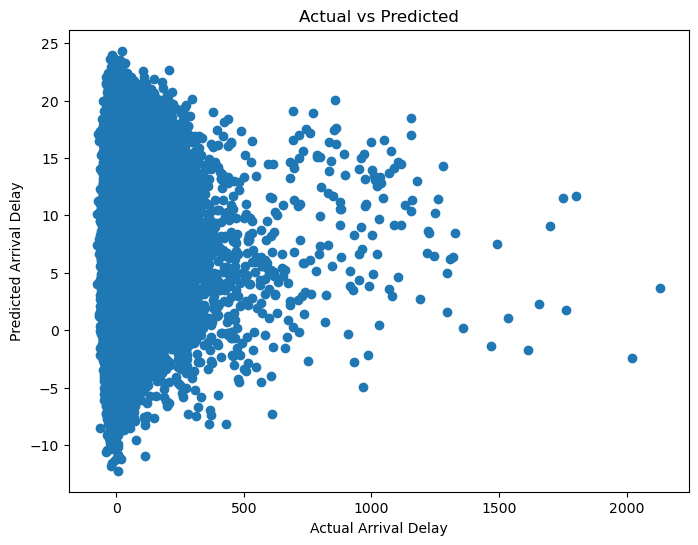

In [157]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Arrival Delay")
plt.ylabel("Predicted Arrival Delay")
plt.title("Actual vs Predicted")
plt.show()

In [158]:
residuals = y_test - y_test_pred

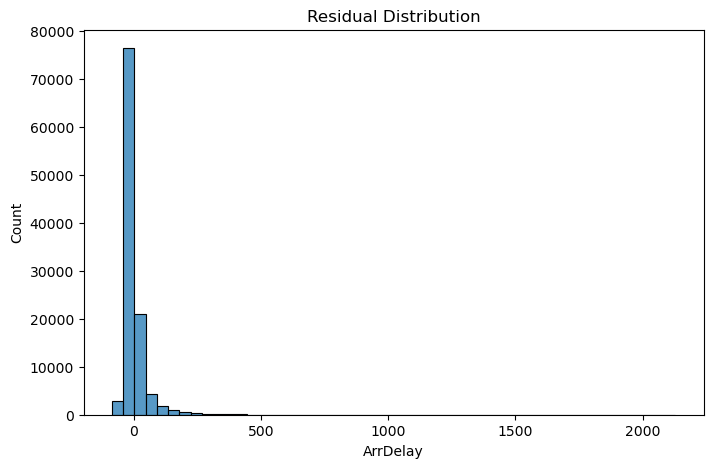

In [92]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=50)

plt.title("Residual Distribution")

plt.show()

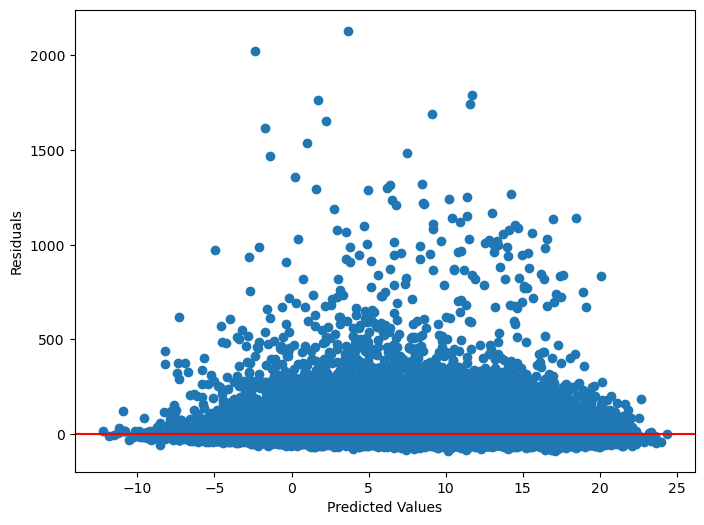

In [93]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.show()

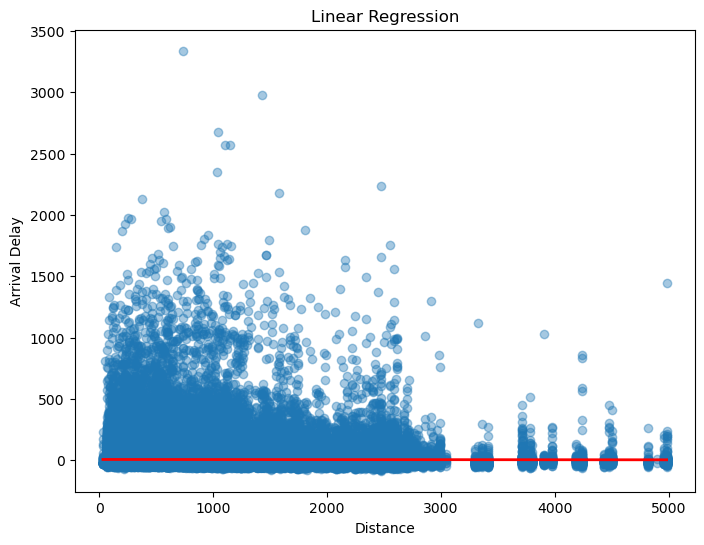

In [94]:
from sklearn.linear_model import LinearRegression

# Select one feature
X = df[['Distance']]
y = df['ArrDelay']

# Remove NaN values
mask = y.notna()
X = X[mask]
y = y[mask]

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
y_predict = model.predict(X)

# Sort for a smooth line
X_sorted = X.sort_values(by='Distance')
y_predict_sorted = model.predict(X_sorted)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X['Distance'], y, alpha=0.4)
plt.plot(X_sorted['Distance'], y_predict_sorted, color='red', linewidth=2)

plt.xlabel("Distance")
plt.ylabel("Arrival Delay")
plt.title("Linear Regression")
plt.show()

In [95]:
# Train the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

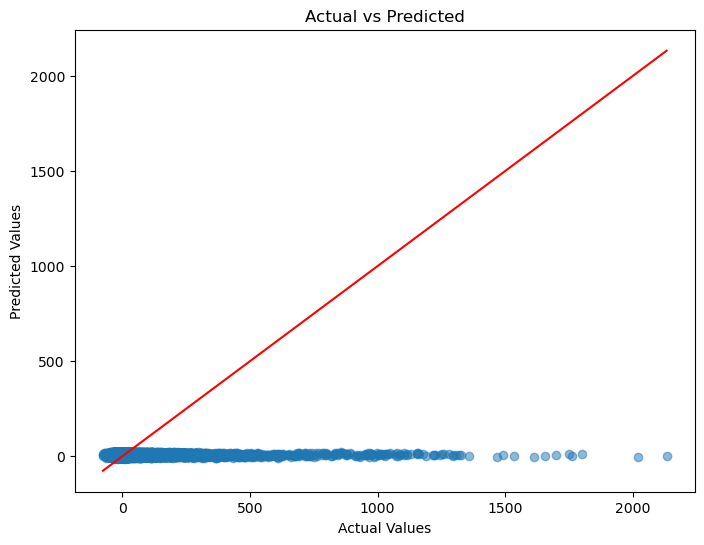

In [96]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [99]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)

In [101]:
# y_pred = model.predict(X_test)

# plt.scatter(y_test, y_pred)
# plt.plot(
#     [y_test.min(), y_test.max()],
#     [y_test.min(), y_test.max()],
#     color='red'
# )

In [102]:
print(model.feature_names_in_)

['Distance']


In [103]:
print(X_test.columns.tolist())

['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'OriginStateFips', 'OriginWac', 'DestStateFips', 'DestWac', 'CRSDepTime', 'CRSArrTime', 'Cancelled', 'Diverted', 'CRSElapsedTime', 'Flights', 'Distance', 'DistanceGroup']


In [105]:
# # Predict
# y_pred = model.predict(X_test)

In [107]:
# y_pred = model.predict(X_test)

# plt.scatter(y_test, y_pred)
# plt.plot(
#     [y_test.min(), y_test.max()],
#     [y_test.min(), y_test.max()],
#     color='red'
# )

In [108]:
X = X.fillna(X.mean())

In [109]:
X = X.fillna("Unknown")

In [110]:
X = X.drop(columns=[
    'Div1Airport',
    'Div2Airport',
    'Div3Airport',
    'Div4Airport',
    'Div5Airport',
    'CancellationCode'
], errors='ignore')

In [111]:
X.isnull().sum().sum()

np.int64(0)

In [112]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])


Series([], dtype: int64)


In [113]:
# Drop columns with more than 50% missing values
threshold = len(df) * 0.5

df = df.dropna(axis=1, thresh=threshold)

In [114]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent[missing_percent > 50])

Series([], dtype: float64)


In [117]:
cols_to_drop = [
'CarrierDelay','WeatherDelay','NASDelay','SecurityDelay','LateAircraftDelay',
'FirstDepTime','TotalAddGTime','LongestAddGTime',
'DivReachedDest','DivActualElapsedTime','DivArrDelay','DivDistance',
'Div1AirportID','Div1AirportSeqID','Div1WheelsOn','Div1TotalGTime',
'Div1LongestGTime','Div1WheelsOff',
'Div2AirportID','Div2AirportSeqID','Div2WheelsOn','Div2TotalGTime',
'Div2LongestGTime','Div2WheelsOff',
'Div3Airport','Div3AirportID','Div3AirportSeqID','Div3WheelsOn',
'Div3TotalGTime','Div3LongestGTime','Div3WheelsOff','Div3TailNum',
'Div4Airport','Div4AirportID','Div4AirportSeqID','Div4WheelsOn',
'Div4TotalGTime','Div4LongestGTime','Div4WheelsOff','Div4TailNum',
'Div5Airport','Div5AirportID','Div5AirportSeqID','Div5WheelsOn',
'Div5TotalGTime','Div5LongestGTime','Div5WheelsOff','Div5TailNum',
'Unnamed: 109'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [118]:
print(df.isnull().sum()[df.isnull().sum() > 0])

DepTime                 25164
DepDelay                25229
DepDelayMinutes         25229
DepDel15                25229
DepartureDelayGroups    25229
TaxiOut                 25515
WheelsOff               25515
WheelsOn                25838
TaxiIn                  25838
ArrTime                 25838
ArrDelay                26781
ArrDelayMinutes         26781
ArrDel15                26781
ArrivalDelayGroups      26781
ActualElapsedTime       26781
AirTime                 26781
dtype: int64
